# Naive Construction of Volatility Surface

In [3]:
import pandas as pd
from src.config import get_config
from src.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

config = get_config()

In [4]:
loader = DataLoader(data_path = "../data")

# Get option data from GS ticker and years 2018-2020
query = f"SELECT {', '.join(config.relevant_option_columns)} FROM options_enriched\
    WHERE date >= '{config.start_date}' and date <= '{config.end_date}'\
    and ticker = 'GS'\
    and tte_days <= {config.max_tte}\
"
df = loader.query(query)

In [5]:
df.head()

,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,strike_price,best_bid,best_offer,...,mid_price,spread,tte_days,tte,tte_months,spot_price,risk_free_rate,forward_price,spread_pct,log_moneyness
0,105329.0,2016-09-16,GS 160916C124000,1,2016-09-16,NaT,C,124000.0,40.1,44.35,...,42.225,4.25,0,0.0,1.0,166.0,0.002481,166.0,0.100651,NaN
1,105329.0,2016-09-16,GS 160916C125000,1,2016-09-16,2016-08-29,C,125000.0,39.1,43.35,...,41.225,4.25,0,0.0,1.0,166.0,0.002481,166.0,0.103093,NaN
2,105329.0,2016-09-16,GS 160916C126000,1,2016-09-16,NaT,C,126000.0,38.1,42.35,...,40.225,4.25,0,0.0,1.0,166.0,0.002481,166.0,0.105656,NaN
3,105329.0,2016-09-16,GS 160916C127000,1,2016-09-16,NaT,C,127000.0,37.1,41.35,...,39.225,4.25,0,0.0,1.0,166.0,0.002481,166.0,0.108349,NaN
4,105329.0,2016-09-16,GS 160916C128000,1,2016-09-16,NaT,C,128000.0,36.1,40.35,...,38.225,4.25,0,0.0,1.0,166.0,0.002481,166.0,0.111184,NaN


In [10]:
def plot_vol_surface(df, plot_day, tte_days):
    """Plots the volatility surface for a given day for options with 30 days to maturity"""
    plt.figure(figsize=(18, 5))
    df_day = df[df['date'] == plot_day]
    print(df_day['tte_days'].unique())
    price_of_day = df_day['spot_price'].values[0]
    for option_type in df_day['cp_flag'].unique():
        df_day_type = df_day[df_day['cp_flag'] == option_type]
        strikes = df_day_type.loc[df_day_type['tte_days'] == tte_days, 'strike'].values
        ivs = df_day_type.loc[df_day_type['tte_days'] == tte_days, 'impl_volatility'].values
        plt.scatter(strikes, ivs, label=f'{option_type}')
    plt.axvline(x=price_of_day, color='red', linestyle='--', label='Price of day', alpha=0.5)
    plt.title(f'Volatility Surface for {plot_day.strftime("%Y-%m-%d")}')
    plt.xlabel('Strike')
    plt.ylabel('Implied Volatility')
    plt.legend()
    plt.show()

2019-07-22 00:00:00
[ 4 11 18 25]


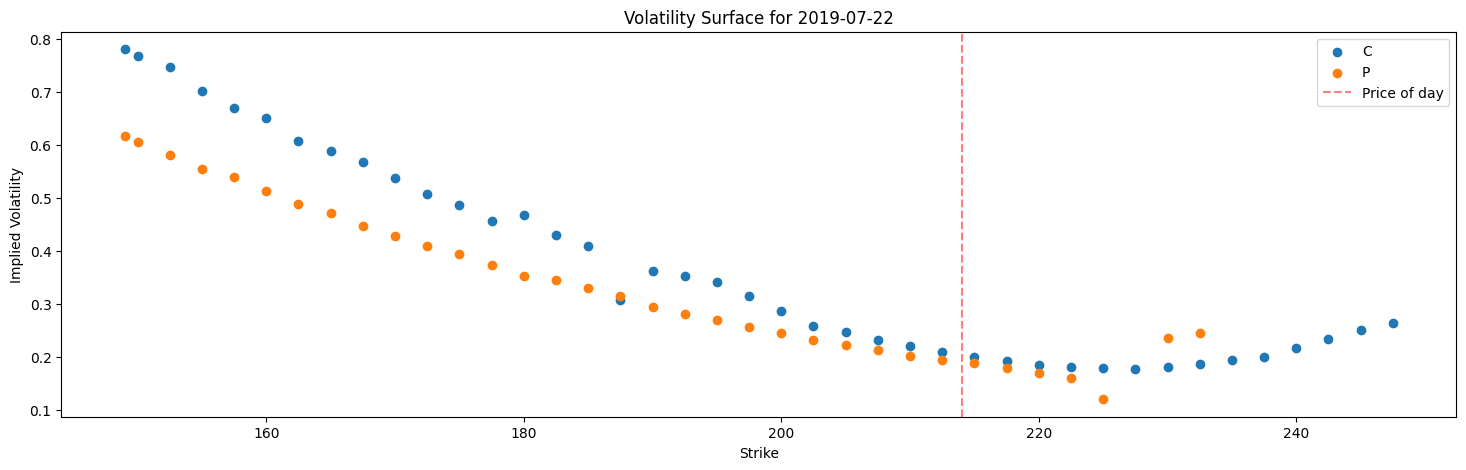

In [11]:

plot_day = datetime(2019, 7, 22)
print(plot_day)
plot_vol_surface(df, plot_day, tte_days=18)